In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint, solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import fsolve
import random
import time

%matplotlib inline
plt.style.use('seaborn-bright')

C:\Users\kgaya\AppData\Local\Temp\ipykernel_26724\4105369326.py:10: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-bright')


In [2]:
# Non-Linear Functions
def f(x, beta, gamma, theta):
    return 1 / (1 + np.exp(-beta * gamma * (x - theta)))

def Fvect(x, **kwargs):
    beta = kwargs.get('beta')
    gamma = kwargs.get('gamma')
    sigma = kwargs.get('sigma')
    theta = kwargs.get('theta')

    vmin = -1 / gamma; vmax = 1 / gamma
    nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)

    if type(x) == np.ndarray and len(x.shape) == 2:
        x = np.repeat(x[:, :, np.newaxis], nsteps, axis=2)

    sigmoid_vals = f(x + v, beta, gamma, theta)
    normal_vals = np.exp(-v ** 2 / (2 * sigma ** 2)) / np.sqrt(2 * np.pi * sigma ** 2)

    return np.sum(dv * sigmoid_vals * normal_vals, axis=-1)

In [3]:
def SingleNodeModel(x, t, **kwargs):
    gamma = kwargs.get('gamma')
    wee = kwargs.get('wee') / gamma; wie = kwargs.get('wie') / gamma
    wei = kwargs.get('wei') / gamma; wii = kwargs.get('wii') / gamma
    alphaE = kwargs.get('alphaE')
    alphaI = kwargs.get('alphaI')
    Ie0 = kwargs.get('ie0') / gamma; Ii0 = kwargs.get('ii0') / gamma

    ext_kwargs = {'beta': kwargs.get('beta'),
                  'gamma': gamma,
                  'theta': kwargs.get('theta'),
                  'sigma': kwargs.get('sigmaE')
                  }

    inh_kwargs = {'beta': kwargs.get('beta'),
                  'gamma': gamma,
                  'theta': kwargs.get('theta'),
                  'sigma': kwargs.get('sigmaI')
                  }
    dEdt = alphaE * (-x[0] + wee * Fvect(x[0], **ext_kwargs) + wie * Fvect(x[1], **inh_kwargs) + Ie0)
    dIdt = alphaI * (-x[1] + wei * Fvect(x[0], **ext_kwargs) + wii * Fvect(x[1], **inh_kwargs) + Ii0)

    return [dEdt, dIdt]

def HeterogeneityModel(x, t, **options):
    gamma = options.get('gamma')
    wee = options.get('wee') / gamma; wie = options.get('wie') / gamma
    wei = options.get('wei') / gamma; wii = options.get('wii') / gamma
    alphaE = options.get('alphaE'); alphaI = options.get('alphaI')
    Ie0 = options.get('ie0') / gamma; Ii0 = options.get('ii0') / gamma
    noise = options.get('noise'); nVar = options.get('D') / gamma ** 2
    dt = options.get('dt')

    ext_kwargs = {'beta': options.get('beta'),
                  'gamma': gamma,
                  'theta': options.get('theta'),
                  'sigma': options.get('sigmaE')
                  }

    inh_kwargs = {'beta': options.get('beta'),
                  'gamma': gamma,
                  'theta': options.get('theta'),
                  'sigma': options.get('sigmaI')
                  }

    dEdt = alphaE * (-x[0] + wee * Fvect(x[0], **ext_kwargs) + wie * Fvect(x[1], **inh_kwargs) + Ie0) + np.sqrt(2 * nVar * dt) * noise(t) / options.get('Ne')
    dIdt = alphaI * (-x[1] + wei * Fvect(x[0], **ext_kwargs) + wii * Fvect(x[1], **inh_kwargs) + Ii0) + np.sqrt(2 * nVar * dt) * noise(t) / options.get('Ni')

    return [dEdt, dIdt]


In [4]:
 def findFixedPoints(minval = -1, maxval = 1, resolution = 75, init_points = 20, **parameters):
    # Define the Grid variable
    minval = minval / parameters.get('gamma')
    maxval = maxval / parameters.get('gamma')

    # Create a grid for evaluation of the vector field
    x1 = np.linspace(minval, maxval, resolution)
    x2 = np.linspace(minval, maxval, resolution)
    x1, x2 = np.meshgrid(x1, x2)

    # Evaluate the slopes
    gradx1, gradx2 = SingleNodeModel([x1, x2], 0, **parameters)

    # Numerical search of stationary points

    fixed_p = []
    y1 = x1.ravel()
    y2 = x2.ravel()

    sample_points = random.sample(list(np.arange(0, resolution ** 2)), k = init_points)

    for i in sample_points:
        # find a zero
        sol, _, ier, _ = fsolve(lambda y : SingleNodeModel(y, 0, **parameters), [y1[i], y2[i]], full_output=1)

        if ier == 1: # Exclude the cases where fsolve didn't converge
            fixed_p.append(sol)

    fixed_p = np.array(fixed_p).T
    print("Fixed points calculated!")

    return gradx1, gradx2, x1, x2, fixed_p

In [5]:
def fprime(x, beta, gamma, theta):
    return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)

def Fprime(x, **kwargs):
    beta = kwargs.get('beta')
    gamma = kwargs.get('gamma')
    sigma = kwargs.get('sigma')
    theta = kwargs.get('theta')

    vmin = -1 / gamma; vmax = 1 / gamma;
    nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)

    # xConv = 0
    # for n in range(nsteps):
    #     v = vmin + n * dv
    #     xConv = xConv + dv * fprime(x + v, beta, gamma, theta) * \
    #                np.exp(-v ** 2 / (2 * sigma ** 2)) / np.sqrt(2 * np.pi * sigma ** 2)
    # return xConv
    if type(x) == np.ndarray and len(x.shape) == 2:
        x = np.repeat(x[:, :, np.newaxis], nsteps, axis=2)

    sigmoid_vals = fprime(x + v, beta, gamma, theta)
    normal_vals = np.exp(-v ** 2 / (2 * sigma ** 2)) / np.sqrt(2 * np.pi * sigma ** 2)

    return np.sum(dv * sigmoid_vals * normal_vals, axis=-1)

def Jacobian(fixed_points, **parameters):
    eigvals = []
    pointtypes = []

    ext_kwargs = {'beta': parameters['beta'],
                  'gamma': parameters['gamma'],
                  'theta': parameters['theta'],
                  'sigma': parameters['sigmaE']
                  }

    inh_kwargs = {'beta': parameters['beta'],
                  'gamma': parameters['gamma'],
                  'theta': parameters['theta'],
                  'sigma': parameters['sigmaI']
                  }

    # Jacobian Analysis
    for i, (fE, fI) in enumerate(fixed_points):
        J = np.zeros((2, 2))

        J[0,0] = parameters['alphaE'] * (-1 + parameters['wee'] / parameters['gamma'] * Fprime(fE, **ext_kwargs))
        J[0,1] = parameters['alphaE'] * parameters['wie'] / parameters['gamma'] * Fprime(fI, **inh_kwargs)
        J[1,0] = parameters['alphaI'] * parameters['wei'] / parameters['gamma'] * Fprime(fE, **ext_kwargs)
        J[1,1] = parameters['alphaI'] * (-1 + parameters['wii'] / parameters['gamma'] * Fprime(fI, **inh_kwargs))

        # Compute and return the eigenvalues
        evals = np.linalg.eig(J)[0]
        eigvals.append(evals)

        # Analysis
        eigval1 = evals[0]
        eigval2 = evals[1]

        if np.imag(eigval1) == 0:
            if np.real(eigval1) < 0 and np.real(eigval2) < 0:
                print(f"Fixed point at {fE, fI} --> Stable Fixed Point", end = " :: ")
                pointtypes.append('green')
            elif np.real(eigval1) == 0 and np.real(eigval2) <= 0 :
                print(f"Fixed point at {fE, fI} --> Neutral Fixed Point", end = " :: " )
                pointtypes.append('blue')
            elif np.real(eigval1) > 0 and np.real(eigval2) < 0:
                print(f"Fixed point at {fE, fI} --> Saddle Point", end = " :: ")
                pointtypes.append('gold')
            else:
                print(f"Fixed point at {fE, fI} --> Unstable Fixed Point ", end = " :: " )
                pointtypes.append('black')

        else:
            if (np.real(eigval1) < 0) and (np.real(eigval2) < 0) and (np.real(eigval1) == np.real(eigval2)):
                print(f"Fixed point at {fE, fI} --> Stable Spiral Focus Point ", end = " :: " )
                pointtypes.append('teal')
            elif np.real(eigval1) == 0 and np.real(eigval2) <= 0 :
                print(f"Fixed point at {fE, fI} --> Neutral Centre", end = " :: ")
                pointtypes.append('red')
            else:
                print(f"Fixed point at {fE, fI} --> Unstable Spiral Focus", end = " :: ")
                pointtypes.append('indigo')

        print(f"Eigen Values: \u03BB1 = {eigval1 :.3f}  \u03BB2 = {eigval2 :.3f}")

    return eigvals, pointtypes

In [6]:
# Plotting

def plotVectField(time_, fixed_points, size = (10, 10), init_points = 5, *args, **options):
    locs = args[0]
    grads = args[1]
    minval = args[2] / options['gamma']; maxval = args[3] / options['gamma']

    # Plotting the vector field in the state space (E, I)
    plt.figure(figsize=size)
    plt.quiver(locs[1], locs[0], grads[1], grads[0], pivot='mid', alpha=.8)
    plt.xlim([minval, maxval])
    plt.ylim([minval, maxval])
    plt.xlabel(r'$I$', fontsize=16)
    plt.ylabel(r'$E$', fontsize=16)
    plt.grid()

    # Numerical ODE integration to plot trajectories
    xE = np.random.uniform(minval, maxval, init_points)
    xI = np.random.uniform(minval, maxval, init_points)

    extensemble = np.zeros((init_points, len(time_)))
    inhensemble = np.zeros((init_points, len(time_)))

    for k, y0 in enumerate(zip(xE, xI)):
        # xSolve = odeint(lambda y, t: HeterogeneityModel(y, t, **params), y0, time)
        # extSolve, inhSolve = xSolve.T

        tic = time.time()
        xSolve = solve_ivp(lambda t, y: HeterogeneityModel(y, t, **options), [0, time_[-1]], y0, method='BDF', t_eval=time_, **{'max_step': 0.1})
        extSolve, inhSolve = xSolve['y']
        toc = time.time()
        print(f'Evaluating with random initialization No. {k + 1} --> Execution time: {toc - tic :.3f}s')

        extensemble[k, :] = extSolve
        inhensemble[k, :] = inhSolve

        # Plot the solution in the state space
        plt.plot(inhSolve, extSolve, '-', )

        # Plot the starting point
        plt.scatter(y0[1], y0[0], marker='*', c='r', s=300, label=f"xE = {y0[0]:.3f} xI = {y0[1]:.3f}")

    # Plot the fixed points identified
    plt.scatter(fixed_points[1], fixed_points[0], marker='o', c='k', s=100,
                label="Stationary points")
    plt.legend(loc="upper left")
    plt.title(f"Vector Field Analysis with \u03C3e = {options.get('sigmaE')}mV, \u03C3i = {options.get('sigmaI')}mV, Ie(t) = {options.get('ie0') / options.get('gamma'):.3f}mV")
    plt.show()

    return extensemble, inhensemble

def plotTimeSeries(ext_series, inh_series, time_, size = (10,10)):
    avg_ext = np.mean(ext_series, axis=0)
    avg_inh = np.mean(inh_series, axis=0)

    # Plot the solution in time
    plt.figure(figsize=size)

    plt.subplot(2, 1, 1)
    plt.ylabel(r'$E$'); plt.xlabel(r'$t$')
    plt.xlim([0, time_[-1]])
    plt.plot(time_[45:], avg_ext[45:], '-', label="excitatory")
    plt.title(f'Excitatory Population Dynamics (Avg. over {ext_series.shape[0]} trials)')

    plt.subplot(2, 1, 2)
    plt.ylabel(r'$I$'); plt.xlabel(r'$t$')
    plt.plot(time_[45:], avg_inh[45:], '-', label="inhibitory");
    plt.xlim([0, time_[-1]])
    plt.title(f'Inhibitory Population Dynamics (Avg. over {ext_series.shape[0]} trials)')
    plt.tight_layout()
    plt.show()

In [7]:
totSim = 250            # 250ms simulation time
dt = 0.1                # Step size

tspan = np.arange(0, totSim, dt)                        # Simulation time array
gausNoise = np.random.normal(0.0, 1.0, len(tspan))      # Creating Gaussian noise array
gausInterp = interp1d(tspan, gausNoise, kind='cubic')   # Look-up table to access the noise points

In [8]:
Isteps = 250
Imax = 0.25; Imin = -0.25
fixedTrack = []
fixedColors = []

for I in range(Isteps):
    iet = I / Isteps * (Imax - Imin)
    params = {
            'wee': 1.6, 'wie': -4.7, 'wei': 3, 'wii': -0.13,
            'beta': 300, 'gamma': 0.016, 'theta': 0.0,
            'ie0': -0.25 + iet, 'ii0': -0.5,
            'sigmaE': 7.8, 'sigmaI': 16.25,
            'alphaE': 1, 'alphaI': 2,
            'D': 0.001, 'noise': gausInterp, 'dt': dt,
            'Ne': 800, 'Ni': 200
        }

    gradx1, gradx2, x1, x2, fixed_p = findFixedPoints(minval=-1, maxval=1, resolution=75, **params)
    uniqfp = np.array(list(set(map(tuple, np.around(fixed_p, 4).T))))   # Unique fixed points
    eigvals, pointtypes = Jacobian(uniqfp, **params)

    fixedTrack.append(uniqfp)
    fixedColors.append(pointtypes)

C:\Users\kgaya\AppData\Local\Temp\ipykernel_26724\1295833176.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))
C:\Users\kgaya\AppData\Local\Temp\ipykernel_26724\156737198.py:2: RuntimeWarning: overflow encountered in square
  return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)


Fixed points calculated!
Fixed point at (-23.5123, -31.2275) --> Stable Fixed Point :: Eigen Values: λ1 = -1.225  λ2 = -1.783
Fixed points calculated!
Fixed point at (-23.3944, -31.2155) --> Stable Fixed Point :: Eigen Values: λ1 = -1.242  λ2 = -1.764
Fixed points calculated!
Fixed point at (-23.2768, -31.2029) --> Stable Fixed Point :: Eigen Values: λ1 = -1.261  λ2 = -1.742
Fixed points calculated!
Fixed point at (-23.1596, -31.1898) --> Stable Fixed Point :: Eigen Values: λ1 = -1.283  λ2 = -1.718
Fixed points calculated!
Fixed point at (-23.0427, -31.1762) --> Stable Fixed Point :: Eigen Values: λ1 = -1.308  λ2 = -1.690
Fixed points calculated!
Fixed point at (-22.9262, -31.162) --> Stable Fixed Point :: Eigen Values: λ1 = -1.339  λ2 = -1.655
Fixed points calculated!
Fixed point at (-22.8101, -31.1471) --> Stable Fixed Point :: Eigen Values: λ1 = -1.382  λ2 = -1.610
Fixed points calculated!
Fixed point at (-22.6943, -31.1317) --> Stable Fixed Point :: Eigen Values: λ1 = -1.468  λ2 = 

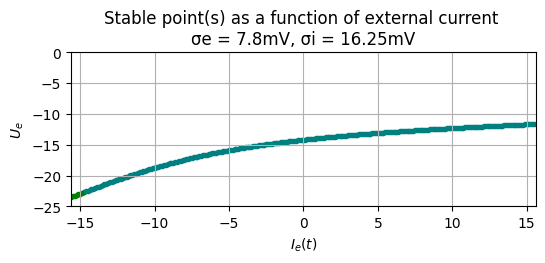

In [9]:
Iet_seq = (Imin + np.arange(0, Isteps) / Isteps * (Imax - Imin)) / params['gamma']

plt.figure(figsize=(6,2))

for k in range(Isteps):
    fixed_point = fixedTrack[k]
    fixed_color = fixedColors[k]

    for fp, color in zip(fixed_point, fixed_color):
        plt.scatter(Iet_seq[k], fp[0], marker='.', c = color)

plt.ylim([-25, 0]); plt.xlim([Imin / params['gamma'], Imax / params['gamma']])
plt.xlabel(r'$I_{e}(t)$'); plt.ylabel(r'$U_e$')
plt.title(f"Stable point(s) as a function of external current \n\u03C3e = {params['sigmaE']}mV, \u03C3i = {params['sigmaI']}mV")
plt.grid()

C:\Users\kgaya\AppData\Local\Temp\ipykernel_26724\1295833176.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))


Fixed points calculated!
Evaluating with random initialization No. 1 --> Execution time: 1.005s
Evaluating with random initialization No. 2 --> Execution time: 1.007s
Evaluating with random initialization No. 3 --> Execution time: 0.982s
Evaluating with random initialization No. 4 --> Execution time: 0.982s
Evaluating with random initialization No. 5 --> Execution time: 0.961s


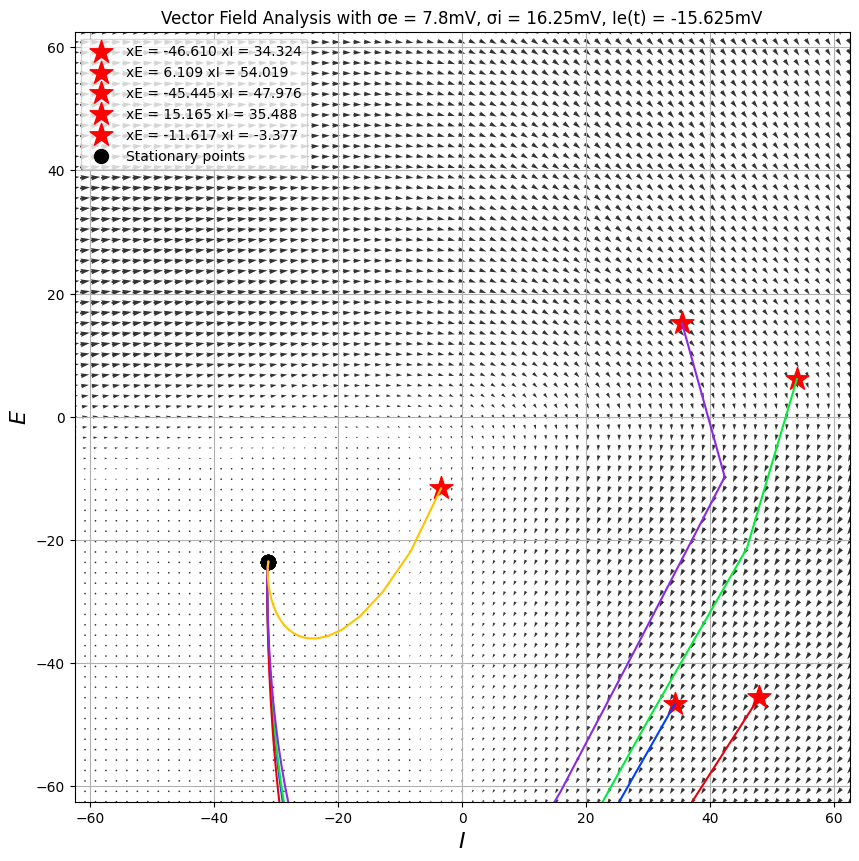

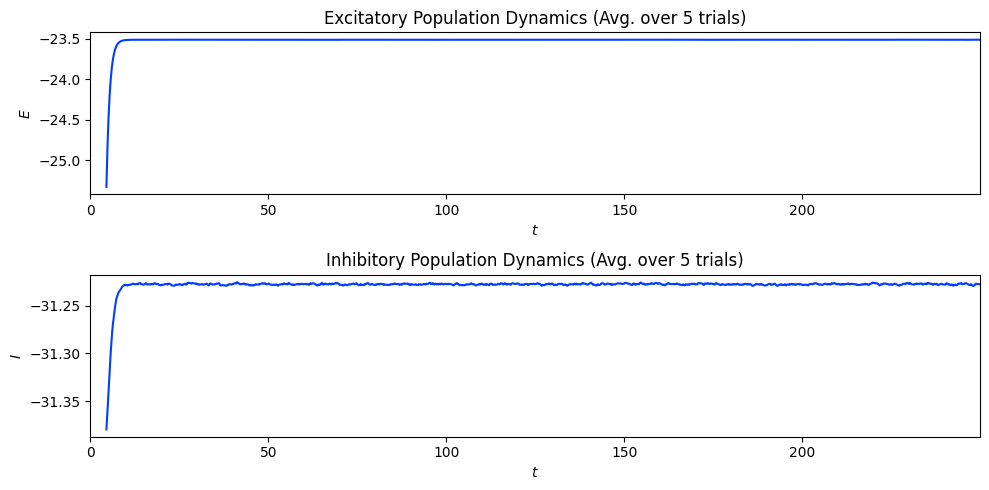

In [10]:
# Plotting

params['ie0'] = Imin
gradx1, gradx2, _, _, tempfp = findFixedPoints(minval=-1, maxval=1, resolution=75, **params)
extSeq, inhSeq = plotVectField(tspan, tempfp, (10, 10), 5, [x1, x2], [gradx1, gradx2], -1, 1, params['gamma'], **params)
plotTimeSeries(extSeq, inhSeq, tspan, size = (10, 5))

C:\Users\kgaya\AppData\Local\Temp\ipykernel_26724\1295833176.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))


Fixed points calculated!
Evaluating with random initialization No. 1 --> Execution time: 0.996s
Evaluating with random initialization No. 2 --> Execution time: 1.002s
Evaluating with random initialization No. 3 --> Execution time: 1.010s
Evaluating with random initialization No. 4 --> Execution time: 1.016s
Evaluating with random initialization No. 5 --> Execution time: 1.173s


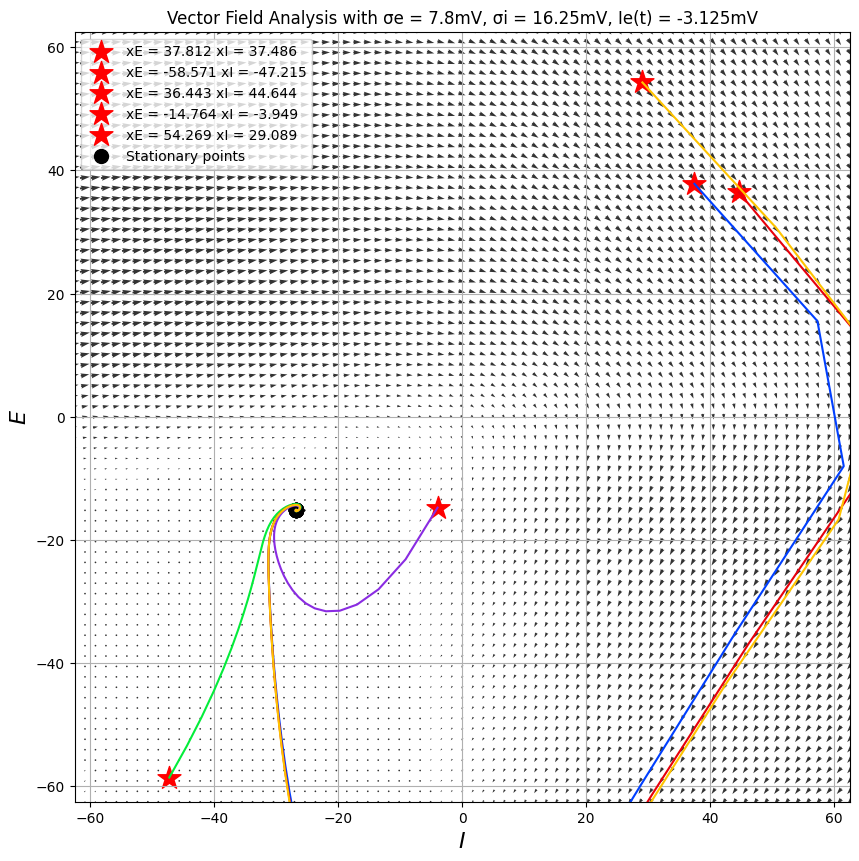

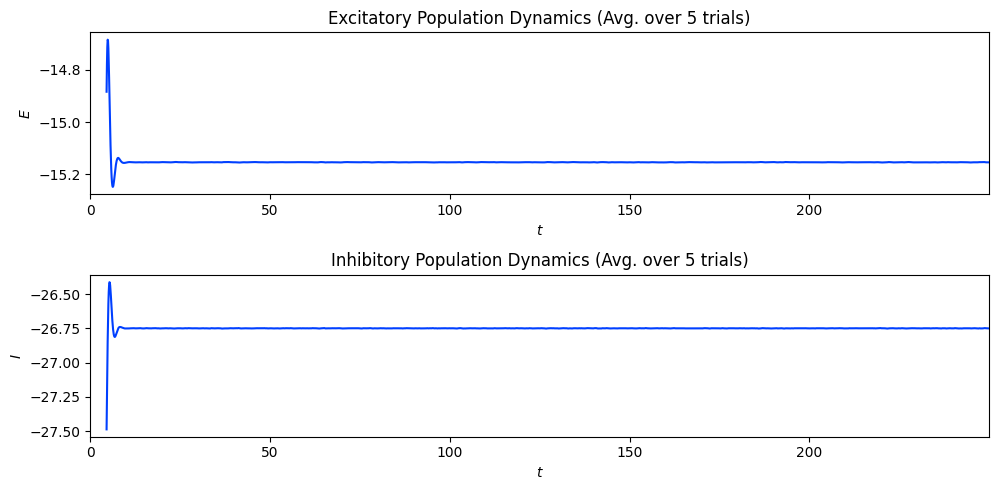

In [11]:
params['ie0'] = Iet_seq[100] * params['gamma']
gradx1, gradx2, _, _, tempfp = findFixedPoints(minval=-1, maxval=1, resolution=75, **params)
extSeq, inhSeq = plotVectField(tspan, tempfp, (10, 10), 5, [x1, x2], [gradx1, gradx2], -1, 1, params['gamma'], **params)
plotTimeSeries(extSeq, inhSeq, tspan, size = (10, 5))

C:\Users\kgaya\AppData\Local\Temp\ipykernel_26724\1295833176.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))


Fixed points calculated!
Evaluating with random initialization No. 1 --> Execution time: 1.001s
Evaluating with random initialization No. 2 --> Execution time: 1.031s
Evaluating with random initialization No. 3 --> Execution time: 1.798s
Evaluating with random initialization No. 4 --> Execution time: 3.937s
Evaluating with random initialization No. 5 --> Execution time: 4.079s


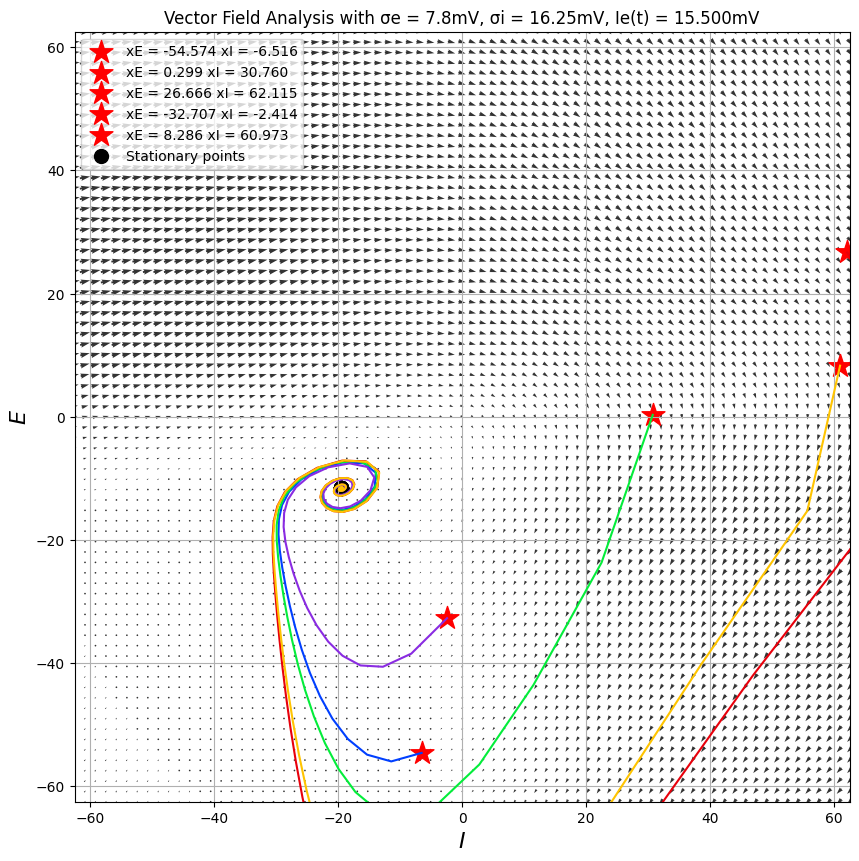

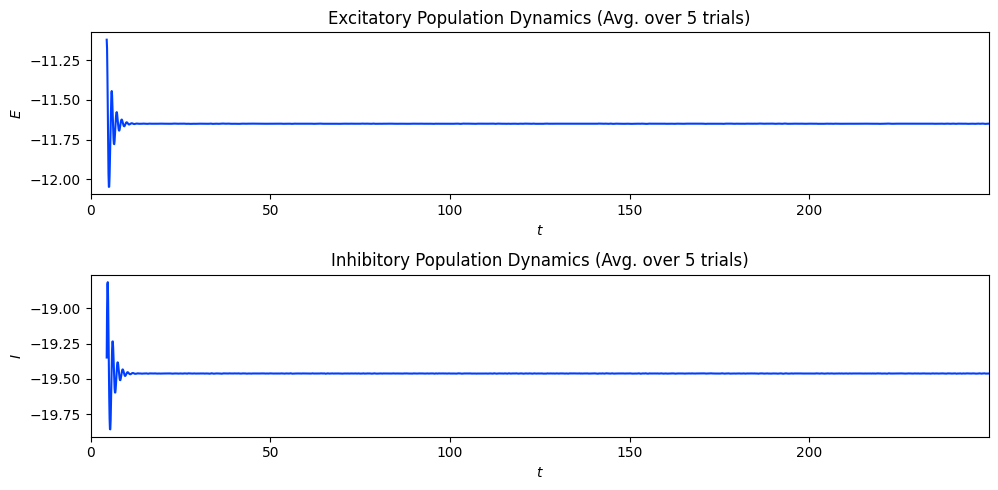

In [12]:
params['ie0'] = Iet_seq[249] * params.get('gamma')
gradx1, gradx2, _, _, tempfp = findFixedPoints(minval=-1, maxval=1, resolution=75, **params)
extSeq, inhSeq = plotVectField(tspan, tempfp, (10, 10), 5, [x1, x2], [gradx1, gradx2], -1, 1, params['gamma'], **params)
plotTimeSeries(extSeq, inhSeq, tspan, size = (10, 5))